In [1]:
## imports

from pygeoinf import data_assimilation as da
import numpy as np
import matplotlib.pyplot as plt
from pygeoinf.data_assimilation.pendulum import single

In [71]:
## ic params
# Initial Condition
# TODO -- vary the initial conditions
true_y0 = np.array([np.deg2rad(45), 1.0])

## obs params
# Define Observations
# TODO -- vary the number and spacing of the observations
n_obs = 5
dt_obs = 25/n_obs

# Set the prior on the initial conditions
# TODO -- this choice can be varied
prior_mean = [0.0, 0.0] # [0.0, 0.0]
cov = 1 # 0.5
prior_cov = np.diag([cov**2, cov**2])

Generating synthetic data...


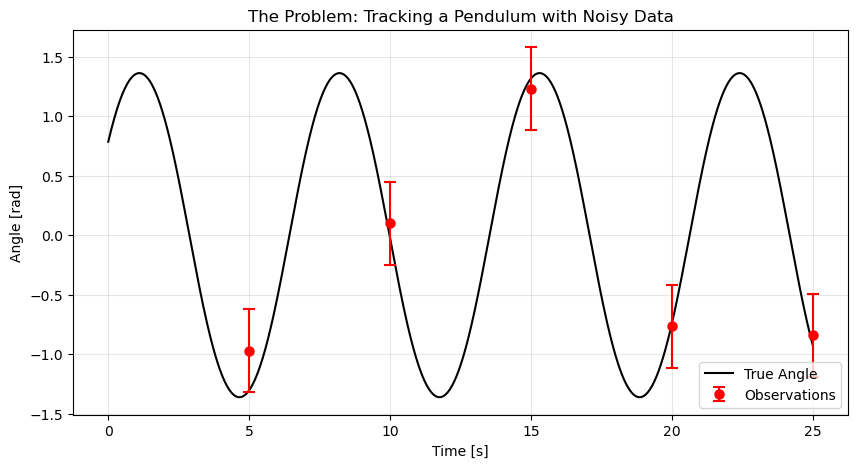

In [72]:


# Create the Assimilation Problem Manager
problem = da.BayesianAssimilationProblem(eom_func=single.eom)



t_obs_points = np.linspace(
    dt_obs,
    dt_obs*n_obs, 
    n_obs
)

# TODO -- vary the observational error. The error
#         stats could change per observation. 
obs_error_sigma = np.deg2rad(10.0) 
R = np.array([[obs_error_sigma**2]])

# Observation Operator for theta
H = np.array([[1.0, 0.0]])

# Register these observations with the problem
print("Generating synthetic data...")
for t in t_obs_points:
    problem.add_observation(
        time=t, covariance=R, operator=H, value=None  
    )

# 5. Generate the "Truth" and the Noisy Data
truth_data = problem.generate_synthetic_data(
    true_initial_condition=true_y0,
    dt_render=0.01    
)

# Visualise the Problem
t_true = truth_data["t_ground_truth"]
y_true = truth_data["state_ground_truth"]
obs_list = problem.observations  # List of (time, model) tuples

plt.figure(figsize=(10, 5))
plt.plot(t_true, y_true[0], "k-", label="True Angle")

# Extract observation values for plotting
t_vals = [t for t, _ in obs_list]
y_vals = [m.y_obs[0] for _, m in obs_list]

plt.errorbar(
    t_vals, y_vals, 
    yerr=2*obs_error_sigma, 
    fmt='ro', 
    capsize=4,             
    elinewidth=1.5,        
    markeredgewidth=1.5,   
    label='Observations'
)

plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("The Problem: Tracking a Pendulum with Noisy Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [73]:
# Set the bounds for the probability grid
# TODO -- the size or resolution of the grid can be varied 
#         higher resolutions will require more computations
bounds = [(-np.pi, np.pi), (-5, 5)]
resolution = [300,300]



prior_pdf = da.get_gaussian_pdf(prior_mean, prior_cov)
initial_prior_grid = da.ProbabilityGrid.from_bounds(
    bounds, 
    resolution, 
    prior_pdf
)

# --- Step C: The Loop (TODO) ---

# initialise some variables
current_grid = initial_prior_grid
manual_history = []
t_current = 0.0

# observation covariance

# Loop through the raw observation times and values
for t_obs, y_observed in zip(t_vals, y_vals):
    
    # 1. Calculate time step to the next observation
    dt = t_obs - t_current

    # Reset variables to None at the start of each iteration
    # This ensures we don't accidentally reuse values from the previous loop
    forecast_grid = None
    analysis_grid = None
    evidence = None
    
    # ============================================================
    # TODO: YOUR CODE HERE
    # ============================================================
    

    # --- TODO TASK 1: FORECAST (The Prior for this step) ---
    # Evolve 'current_grid' forward by dt to create the 'forecast_grid'.
    # Hint: Use current_grid.push_forward(...). You will need to provide
    # the dynamic rule for the system which is stored in 'problem.eom_func'
    
    # forecast_grid = ...

    forecast_grid = current_grid.push_forward(problem.eom_func, dt)

    # --- TODO TASK 2: OBSERVE (The Likelihood) ---
    #  A. Create a LinearGaussianLikelihood object associated with 
    #     the current observation. 
    
    # lik_model = da.LinearGaussianLikelihood(...)

    lik_model = da.LinearGaussianLikelihood(y_observed, R, H)

    # B. Evaluate this likelihood on the forecast_grid to get 'lik_grid'.
    
    # lik_grid = ...

    lik_grid = lik_model.evaluate(forecast_grid)


    # --- TODO TASK 3: ANALYSIS (Bayes' Theorem) ---
    # We want: Posterior = (Prior * Likelihood) / Evidence
    
    # A. Calculate the unnormalised posterior (Numerator)
    # Hint: ProbabilityGrid supports element-wise multiplication using '*'
    
    # unnorm_posterior = ...

    unnorm_posterior = forecast_grid * lik_grid
    
    
    # B. Calculate the Evidence (Denominator)
    # This is the total probability mass (integral) of the unnormalised grid.
    # Hint: ProbabilityGrid has a property 'total_mass' that returns the 
    #       necessary integral approximated using quadrature
    
    # evidence = ...

    evidence = unnorm_posterior.total_mass
    
    
    # C. Calculate the Final Posterior (Normalisation)
    # Divide the unnormalised grid by the evidence.
    
    # analysis_grid = ...
   
    analysis_grid = unnorm_posterior / evidence

    # ============================================================
    # END YOUR CODE
    # ============================================================
    
    
    # Safety mock: If variables are still None use the current_grid
    # so the script doesn't crash.
    if forecast_grid is None: forecast_grid = current_grid
    if analysis_grid is None: analysis_grid = current_grid
    if evidence is None: evidence = 1.0
    

    # Store result for plotting
    manual_history.append({
        'time': t_obs,
        'forecast': forecast_grid,
        'analysis': analysis_grid,
        'evidence': evidence
    })
    
    # Update state for next iteration
    current_grid = analysis_grid
    t_current = t_obs
    print(f"Assimilated y={y_observed:.2f} at t={t_obs:.2f}")

Assimilated y=-0.97 at t=5.00
Assimilated y=0.10 at t=10.00
Assimilated y=1.23 at t=15.00
Assimilated y=-0.77 at t=20.00
Assimilated y=-0.84 at t=25.00



Running reanalysis...
Sampling and reconstructing trajectories...


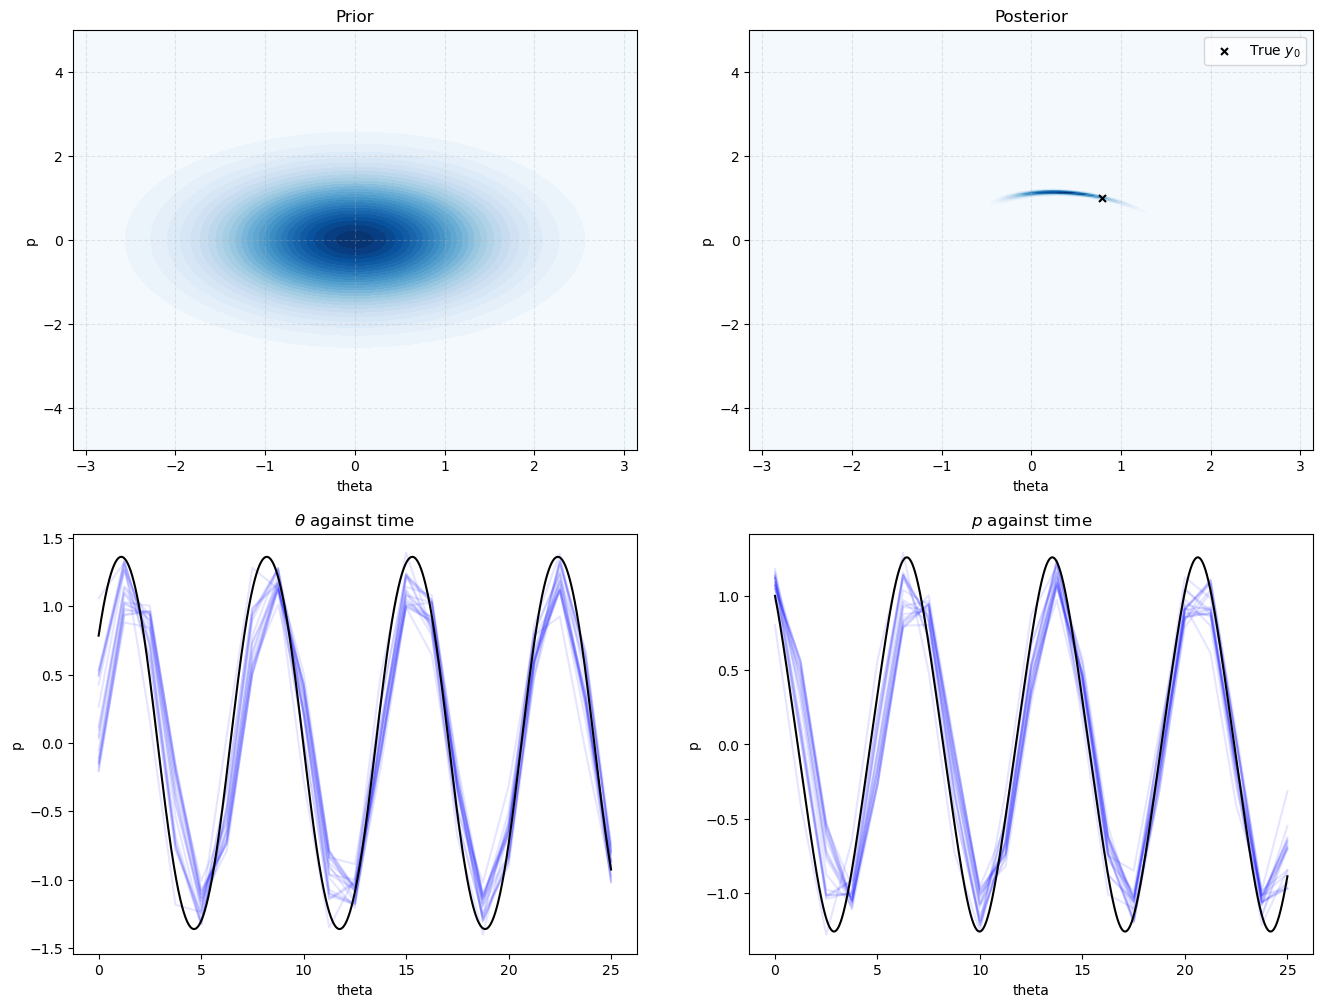

In [74]:
automated_history = problem.run(initial_prior_grid)

# 2. Compare the Final Posteriors
#    We will plot your manual result vs the automated result side-by-side.
manual_final = manual_history[-1]['analysis']
auto_final = automated_history[-1]['analysis']
final_time = t_vals[-1]

plot_t_vals = np.linspace(0, final_time, 21)

fig, axs = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'xlabel': 'theta', 'ylabel': 'p'})
axs = axs.flatten()

# We will now use the final posterior to learn about the past.
# You have the 'manual_final' grid from the end of your loop.
# You also have the final time 'final_time'.

print("\nRunning reanalysis...")

# --- TODO STEP 1: Obtain the Smoothed Initial Distribution ---
# 1. Take the final posterior grid ('manual_final')
# 2. Propagate it BACKWARDS in time to t=0 using the system dynamics.
#
# Hint: The method 'push_forward' takes a time step 'dt'. 
#       If you want to go back to the start, what should 'dt' be?

# --- SOLUTION ---

initial_posterior_grid = manual_final.push_forward(problem.eom_func, -1 * final_time)

# ----------------


# --- TODO STEP 2: Visualise the Improvement ---
# Plot the posterior for the initial conditions and compare to the prior
# to see how much information we gained from the future observations.
#
# Hint: Use da.plot_grid_marginal just like in the verification step.

# --- SOLUTION ---

da.plot_grid_marginal(initial_posterior_grid, ax=axs[1], cmap='Blues')
axs[0].set_title('Prior')
axs[1].set_title('Posterior')
da.plot_grid_marginal(initial_prior_grid, ax=axs[0], cmap='Blues')

axs[1].scatter(true_y0[0], true_y0[1], s=25, marker='x', c='k', label='True $y_0$')
axs[1].legend()

# ----------------


# --- TODO STEP 3: Reconstruct Trajectories ---
# Now we want to see the "bundle" of trajectories that are consistent with our data.
#
# 1. Sample points from your 'initial_posterior_grid'.
#    Hint: The ProbabilityGrid class has a .sample(n_samples) method.
#
# 2. For each sampled point, simulate the trajectory forward from t=0 to final_time.
#    Hint: Use da.solve_trajectory(...).
#
# 3. Plot these trajectories on top of the observations.
#    - Plot theta vs time in one subplot.
#    - Plot p (velocity) vs time in a second subplot.
#    - Use alpha=0.1 so the overlapping lines show the density of paths.

print("Sampling and reconstructing trajectories...")

# --- SOLUTION ---

n_samples = 20
samples = initial_posterior_grid.sample(n_samples)

for sample in samples:
    reanalysis_final = da.solve_trajectory(problem.eom_func, sample, plot_t_vals)

    axs[2].set_title('$\\theta$ against time')
    axs[2].plot(
        plot_t_vals, reanalysis_final[0], alpha=0.1, color='blue'
    )

    axs[3].set_title('$p$ against time')
    axs[3].plot(
        plot_t_vals, reanalysis_final[1], alpha=0.1, color='Blue'
    )

axs[2].plot(t_true, y_true[0], "k-", label="True Angle")
axs[3].plot(t_true, y_true[1], "k-", label="True Angle")
# ----------------

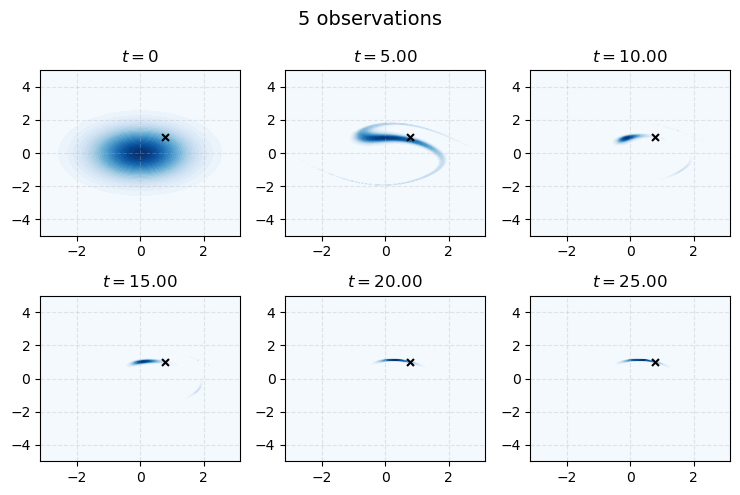

In [75]:
## plot of various posteriors when pushed back at different points in time

plot_history = []
an_times = [5, 10, 15, 20, 25]
for item in manual_history:
    if item['time'] in an_times:
        plot_history.append(item)

n_axs = len(plot_history)

#fig, axs = plt.subplots((n_axs+1) // 2, 2, figsize=(n_axs, n_axs*1.5))
fig, axs = plt.subplots(2, (n_axs+1) // 2, figsize=(n_axs*1.5, n_axs))
axs = axs.flatten()


da.plot_grid_marginal(initial_prior_grid, ax=axs[0], cmap='Blues')
axs[0].scatter(true_y0[0], true_y0[1], s=25, marker='x', c='k', label='True $y_0$')
axs[0].set_title('$t=0$')

for i, item in enumerate(plot_history):
    man_final = item['analysis']
    t_final = item['time']

    initial_post_grid = man_final.push_forward(problem.eom_func, -1 * t_final)

    da.plot_grid_marginal(initial_post_grid, ax=axs[i+1], cmap='Blues')

    axs[i+1].scatter(true_y0[0], true_y0[1], s=25, marker='x', c='k', label='True $y_0$')
    axs[i+1].set_title(f'$t={t_final:.2f}$')

fig.suptitle('5 observations', size='14')
plt.tight_layout()